# import libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_excel("ecommerce data.xlsx")

In [12]:
df

,Order ID,Order Date,Ship Date,Aging,Ship Mode,Product Category,Product,Sales,Quantity,Discount,...,Shipping Cost,Order Priority,Customer ID,Customer Name,Segment,City,State,Country,Region,Months
0,AU-2015-1,42317.0,42325,8.0,First Class,Auto & Accessories,Car Media Players,140,2,0.05,...,4.6,Medium,LS-001,Lane Daniels,Consumer,Brisbane,Queensland,Australia,Oceania,Nov
1,AU-2015-2,42185.0,42187,2.0,First Class,Auto & Accessories,Car Speakers,211,3,0.03,...,11.2,Medium,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Jun
2,AU-2015-3,42343.0,42351,8.0,First Class,Auto & Accessories,Car Body Covers,117,5,0.01,...,3.1,Critical,EN-003,Moon Weien,Consumer,Porirua,Wellington,New Zealand,Oceania,Dec
3,AU-2015-4,42133.0,42140,7.0,First Class,Auto & Accessories,Car & Bike Care,118,2,0.05,...,2.6,High,AN-004,Sanchez Bergman,Corporate,Kabul,Kabul,Afghanistan,Central Asia,May
4,AU-2015-5,42194.0,42203,9.0,First Class,Auto & Accessories,Tyre,250,1,0.04,...,16,Critical,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Jul
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,FA-2015-30771,42025.0,42031,6.0,Standard Class,Fashion,Sports Wear,85,5,0.04,...,1.7,Medium,IN-0040977,Welch Fein,Corporate,Pasadena,Texas,United States,Central,Jan
51286,FA-2015-30772,42177.0,42179,2.0,Standard Class,Fashion,Sports Wear,85,1,0.03,...,0.2,Medium,TT-0040978,Martinez Arnett,Corporate,Harare,Harare,Zimbabwe,Africa,Jun
51287,FA-2015-30773,42005.0,42011,6.0,Standard Class,Fashion,Sports Wear,85,1,0.05,...,0.1,Medium,ON-0040979,Mccoy Duston,Home Office,Townsville,Queensland,Australia,Oceania,Jan
51288,FA-2015-30774,42345.0,42352,7.0,Standard Class,Fashion,Sports Wear,85,3,0.04,...,2.8,Medium,RN-0040980,Bentley Zypern,Consumer,Houston,Texas,United States,Central,Dec


In [13]:
df.dtypes

Order ID                str
Order Date          float64
Ship Date             int64
Aging               float64
Ship Mode            object
Product Category        str
Product                 str
Sales                object
Quantity             object
Discount             object
Profit              float64
Shipping Cost        object
Order Priority          str
Customer ID             str
Customer Name           str
Segment                 str
City                    str
State                   str
Country                 str
Region                  str
Months                  str
dtype: object

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [1]:
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Cost"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("₹", "", regex=False)
    )

NameError: name 'df' is not defined

In [17]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")
df["Shipping Cost"] = pd.to_numeric(df["Shipping Cost"], errors="coerce")

In [18]:
df["Aging"] = pd.to_numeric(df["Aging"], errors="coerce")

In [19]:
categorical_cols = [
    "Order ID",
    "Ship Mode",
    "Product Category",
    "Product",
    "Order Priority",
    "Customer ID",
    "Customer Name",
    "Segment",
    "City",
    "State",
    "Country",
    "Region",
    "Months"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

In [20]:
print(df.dtypes)

Order ID                  category
Order Date          datetime64[ns]
Ship Date                    int64
Aging                      float64
Ship Mode                 category
Product Category          category
Product                   category
Sales                      float64
Quantity                   float64
Discount                   float64
Profit                     float64
Shipping Cost              float64
Order Priority            category
Customer ID               category
Customer Name             category
Segment                   category
City                      category
State                     category
Country                   category
Region                    category
Months                    category
dtype: object


# 1.Overall Sales Performance

In [ ]:
print("\n========== OVERALL SALES PERFORMANCE ==========\n")

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_shipping = df["Shipping Cost"].sum()

print("Total Sales :", round(total_sales,2))
print("Total Profit :", round(total_profit,2))
print("Total Quantity :", total_quantity)
print("Total Shipping Cost :", round(total_shipping,2))

# 2.Top 10 Best-Selling Products

In [ ]:
print("\n========== TOP 10 PRODUCTS ==========\n")

top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh",color="royalblue")
plt.title("Top 10 Best Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# 3.Product Category Analysis

In [ ]:
print("\n========== CATEGORY ANALYSIS ==========\n")

category = df.groupby("Product Category").agg({
    "Sales":"sum",
    "Profit":"sum",
    "Quantity":"sum"
})

print(category)

category.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Category Analysis")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

# 4.Monthly Sales Trend

In [ ]:
print("\n========== MONTHLY SALES TREND ==========\n")

monthly_sales = (
    df.groupby("Months")["Sales"]
    .sum()
)

print(monthly_sales)

plt.figure(figsize=(12,5))
monthly_sales.plot(
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


# 5.Regional Sales Analysis


========== REGIONAL SALES ==========

                    Sales    Profit
Region                             
4orth               117.0      33.5
Africa           713074.0  332220.0
Canada            60003.0   27783.1
Caribbean        260495.0  120608.1
Central         1735900.0  804210.0
Central Asia     321005.0  149529.7
EMEA             788072.0  368570.7
East             446468.0  206694.5
North            750365.0  349269.5
North Asia       369816.0  170918.3
Oceania          544827.0  253691.7
So3th               211.0      99.4
South           1034533.0  479016.5
Southeast Asia   500712.0  235598.1
West             497432.0  231775.8


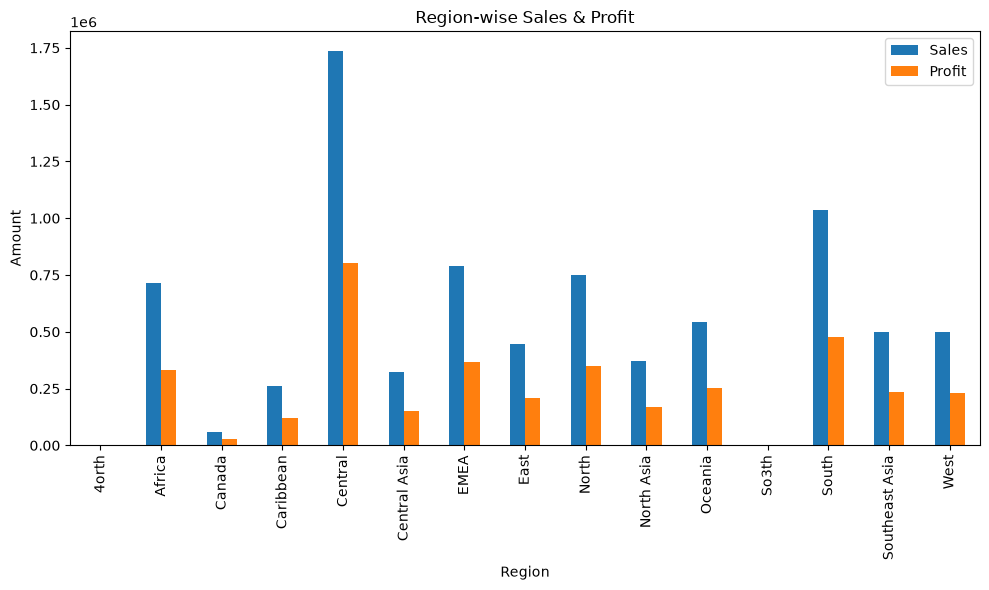


Most Profitable Region:
Central


In [21]:
print("\n========== REGIONAL SALES ==========\n")

region = df.groupby("Region").agg({
    "Sales":"sum",
    "Profit":"sum"
})

print(region)

region.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Region-wise Sales & Profit")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

print("\nMost Profitable Region:")
print(region["Profit"].idxmax())

# 6.Country-wise Revenue Analysis


========== COUNTRY-WISE REVENUE ==========

Country
United States     1562170.0
Australia          442452.0
France             437441.0
Mexico             418795.0
Germany            323619.0
China              296640.0
United Kingdom     253975.0
Brazil             247794.0
India              244746.0
Indonesia          222379.0
Name: Sales, dtype: float64


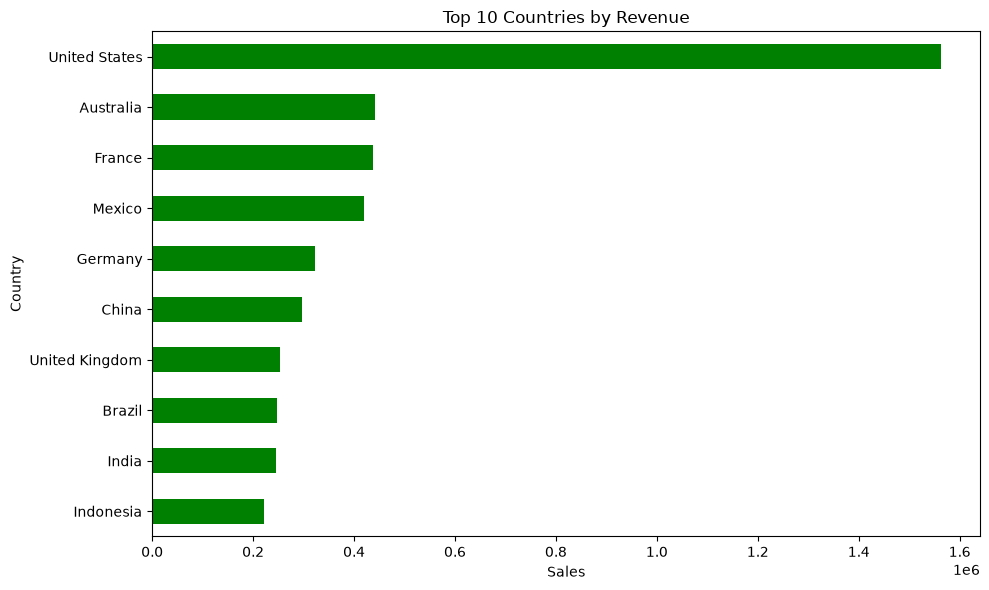

In [22]:
print("\n========== COUNTRY-WISE REVENUE ==========\n")

country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_sales)

plt.figure(figsize=(10,6))
country_sales.sort_values().plot(
    kind="barh",
    color="green"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# 7.State-wise Profit Analysis

In [ ]:
print("\n========== STATE-WISE PROFIT ==========\n")

state_profit = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

top15 = state_profit.head(15)
bottom15 = state_profit.tail(15)

print("\nTop 15 States")
print(top15)

print("\nBottom 15 States")
print(bottom15)

plt.figure(figsize=(10,6))
top15.sort_values().plot(
    kind="barh",
    color="blue"
)

plt.title("Top 15 States by Profit")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
bottom15.plot(
    kind="barh",
    color="red"
)

plt.title("Bottom 15 States by Profit")
plt.tight_layout()
plt.show()

# 8.Customer Segment Analysis


========== CUSTOMER SEGMENT ANALYSIS ==========

                 Sales     Profit  Quantity
Segment                                    
Consumer     4135010.0  1915800.9   79659.0
Corporate    2421560.0  1128812.0   46109.0
Home Office  1466528.0   685446.0   27956.0


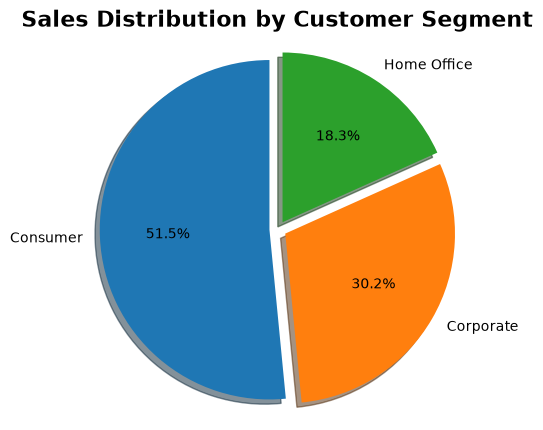

In [23]:
print("\n========== CUSTOMER SEGMENT ANALYSIS ==========\n")

segment = df.groupby("Segment").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
})

print(segment)

# Pie Chart for Sales by Customer Segment
plt.figure(figsize=(5,5))

plt.pie(
    segment["Sales"],
    labels=segment.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05]*len(segment),
    shadow=True
)

plt.title("Sales Distribution by Customer Segment", fontsize=16, fontweight="bold")

plt.axis("equal")
plt.show()

# 9.Ship Mode Performance


========== SHIP MODE PERFORMANCE ==========

                Avg_Shipping_Cost  Avg_Aging  Total_Sales
Ship Mode                                                
45788                    0.600000   9.000000        114.0
First Class              6.454165   5.541850    1096814.0
Same Day                 6.455313   1.000000     394738.0
Second Class             5.703114   5.454845    1319407.0
Standard Class           8.070382   5.491503    5212097.0


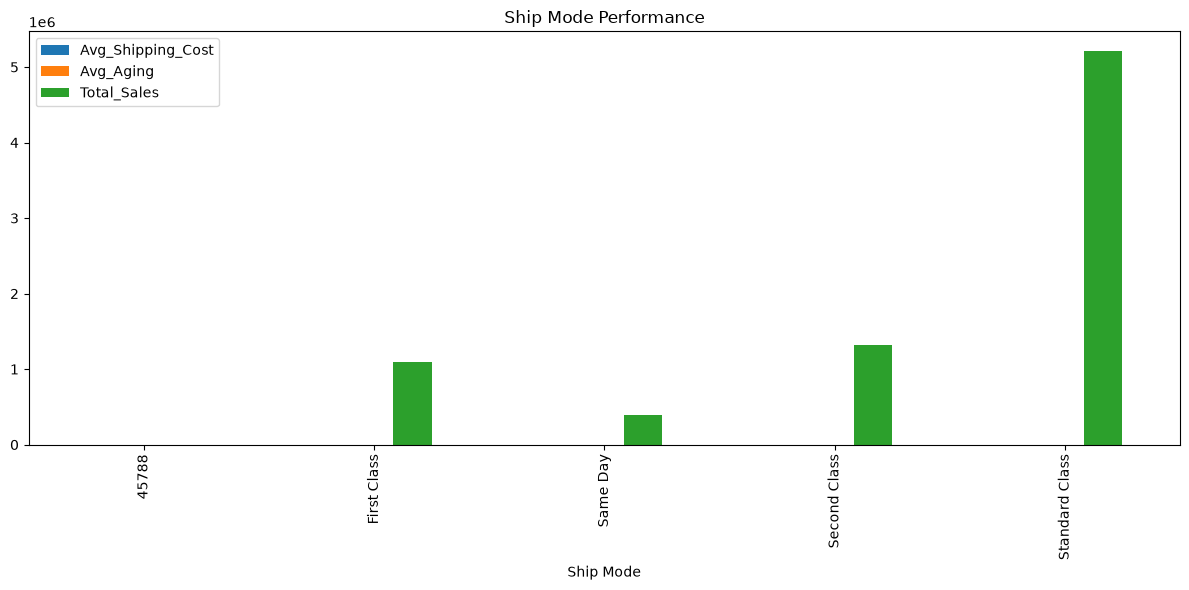

In [24]:
print("\n========== SHIP MODE PERFORMANCE ==========\n")

ship = df.groupby("Ship Mode").agg(
    Avg_Shipping_Cost=("Shipping Cost","mean"),
    Avg_Aging=("Aging","mean"),
    Total_Sales=("Sales","sum")
)

print(ship)

ship.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Ship Mode Performance")
plt.tight_layout()
plt.show()

# 10.Discount vs Profit Analysis


========== DISCOUNT VS PROFIT ==========

Correlation = -0.119


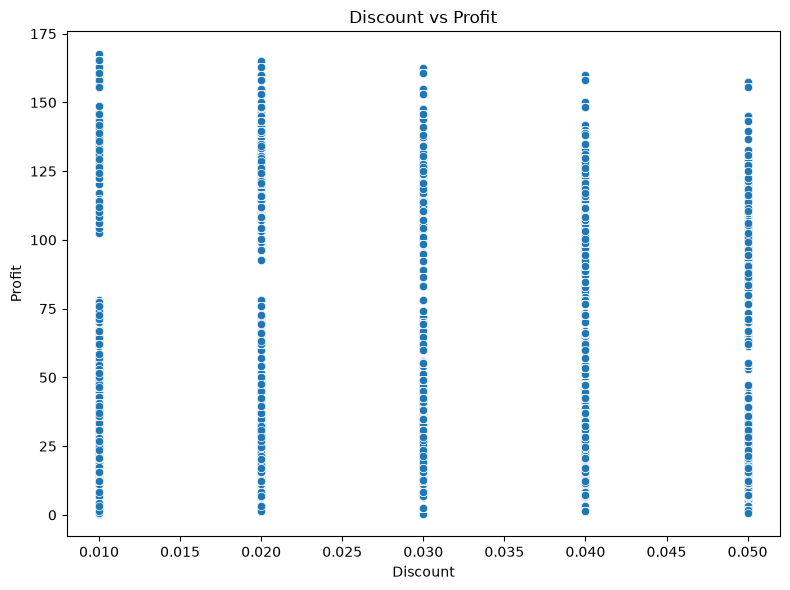

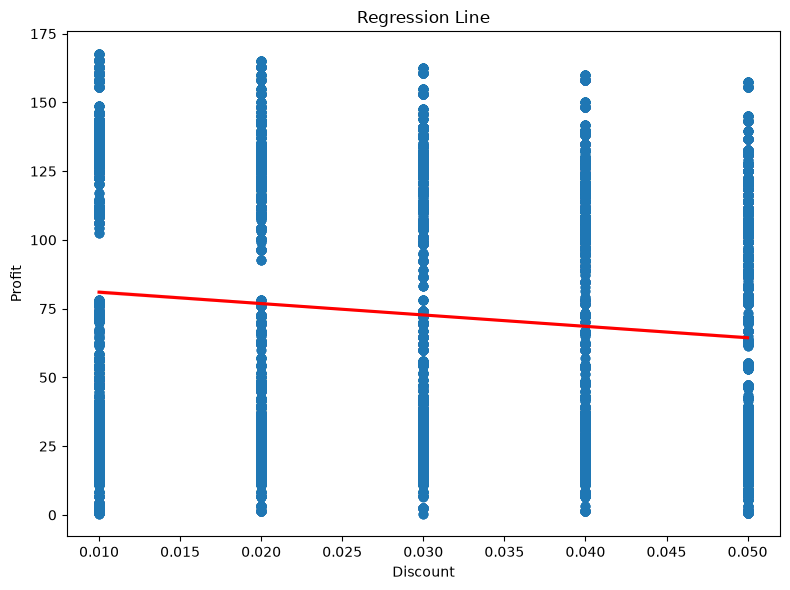

In [25]:
print("\n========== DISCOUNT VS PROFIT ==========\n")

correlation = df["Discount"].corr(df["Profit"])

print("Correlation =", round(correlation,3))

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Regression Line")
plt.tight_layout()
plt.show()

# 11.Order Priority Analysis

In [ ]:
print("\n========== ORDER PRIORITY ANALYSIS ==========\n")

priority = df.groupby("Order Priority").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

print(priority)

priority.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Order Priority Analysis")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

print("\nHighest Revenue Priority:")
print(priority["Total_Sales"].idxmax())

# 12.Top Customers Analysis


========== TOP 20 CUSTOMERS ==========

                   Total_Sales  Total_Profit
Customer Name                               
Mcclain O'Donnell      17015.0        7592.2
Weber Halladay         16632.0        7877.1
Leon Sissman           16321.0        7960.3
Booth Pistole          16291.0        7707.6
Ellis Carmichael       16174.0        7891.9
Bates Gockenbach       15968.0        7545.8
Bell Bickford          15932.0        7748.0
Spears Thornton        15922.0        7443.6
Graves Garza           15833.0        7830.7
Flores Brooks          15807.0        7250.5
Robertson Coakley      15635.0        7529.7
Kelly Braden           15593.0        7418.9
Skinner Nguyen         15332.0        7269.1
Ryan Dominguez         15160.0        7132.2
Mcdowell Roelle        15048.0        6838.7
Preston Savely         15010.0        7165.0
Barnett Garverick      14946.0        7321.4
Wiley Pölking          14883.0        7234.3
Oneill Williams        14719.0        6853.8
Meyers Pelleti

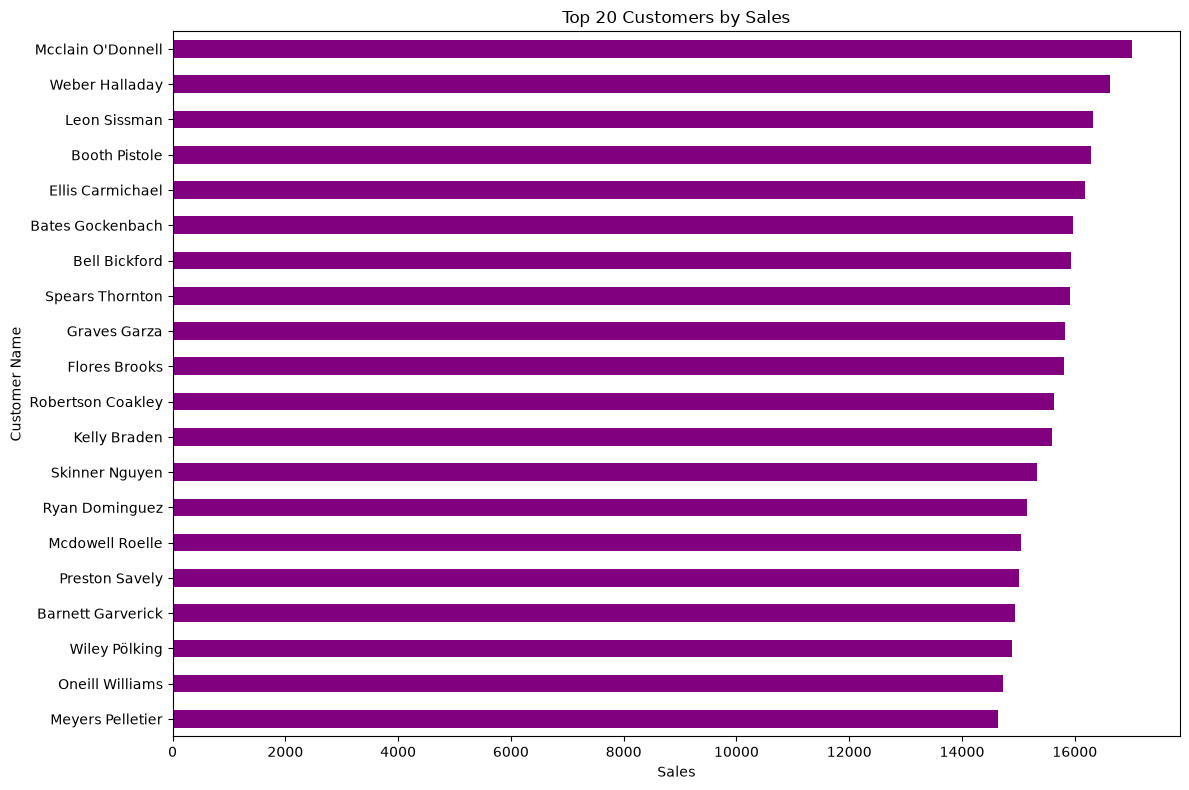

In [26]:
print("\n========== TOP 20 CUSTOMERS ==========\n")

top_customers = (
    df.groupby("Customer Name")
      .agg(
          Total_Sales=("Sales","sum"),
          Total_Profit=("Profit","sum")
      )
      .sort_values(by="Total_Sales", ascending=False)
      .head(20)
)

print(top_customers)

plt.figure(figsize=(12,8))

top_customers["Total_Sales"].sort_values().plot(
    kind="barh",
    color="purple"
)

plt.title("Top 20 Customers by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

# 13.Loss-Making Orders

In [ ]:
print("\n========== LOSS MAKING ORDERS ==========\n")

loss_orders = df[df["Profit"] < 0]

print("Total Loss Orders :", len(loss_orders))

print(loss_orders[[
    "Order ID",
    "Product Category",
    "Sales",
    "Discount",
    "Shipping Cost",
    "Profit"
]])

print("\nAverage Discount:")
print(loss_orders["Discount"].mean())

print("\nAverage Shipping Cost:")
print(loss_orders["Shipping Cost"].mean())

print("\nLoss Orders by Category:")
print(loss_orders["Product Category"].value_counts())


# Aging Analysis

In [ ]:
print("\n========== AGING ANALYSIS ==========\n")

aging = df.groupby("Ship Mode")["Aging"].mean()

print(aging)

plt.figure(figsize=(8,5))

aging.sort_values().plot(
    kind="bar",
    color="orange"
)

plt.title("Average Delivery Aging")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

print("\nFastest Shipping Method:")
print(aging.idxmin())

# 15.Sales Distribution

In [ ]:
print("\n========== SALES DISTRIBUTION ==========\n")

plt.figure(figsize=(10,5))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Boxplot")
plt.tight_layout()
plt.show()

# 16.Profit Distribution by Category

In [ ]:
print("\n========== PROFIT DISTRIBUTION BY CATEGORY ==========\n")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Profit"
)

plt.title("Profit Distribution by Product Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="Product Category",
    y="Profit"
)

plt.title("Profit Distribution (Violin Plot)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 17.Correlation Analysis Matrix

In [ ]:
print("\n========== CORRELATION ANALYSIS ==========\n")

corr = df[[
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Cost",
    "Aging"
]].corr()

print(corr)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 18.High-Value Orders

In [ ]:
print("\n========== HIGH VALUE ORDERS ==========\n")

avg_sales = df["Sales"].mean()

high_value = df[df["Sales"] > avg_sales]

print("Average Sales :", round(avg_sales,2))
print("Number of High Value Orders :", len(high_value))

print(high_value[[
    "Order ID",
    "Customer Name",
    "Product",
    "Sales",
    "Profit",
    "Region"
]].head(20))

print("\nCategory Distribution")
print(high_value["Product Category"].value_counts())

print("\nRegion Distribution")
print(high_value["Region"].value_counts())

# 19.Customer Purchase Frequency

In [ ]:
print("\n========== CUSTOMER PURCHASE FREQUENCY ==========\n")

purchase_frequency = (
    df.groupby("Customer Name")
      .agg(
          Number_of_Orders=("Order ID","count"),
          Total_Sales=("Sales","sum"),
          Average_Order_Value=("Sales","mean")
      )
      .sort_values(by="Number_of_Orders", ascending=False)
)

print(purchase_frequency.head(20))

repeat_customers = purchase_frequency[
    purchase_frequency["Number_of_Orders"] > 1
]

print("\nRepeat Customers :", len(repeat_customers))

plt.figure(figsize=(12,8))

purchase_frequency.head(20)["Number_of_Orders"].sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title("Top 20 Customers by Number of Orders")
plt.xlabel("Orders")
plt.tight_layout()
plt.show()

# 20.Executive Sales Dashboard

In [ ]:
print("\n========== EXECUTIVE SALES DASHBOARD ==========\n")

print("Total Sales :", round(df["Sales"].sum(),2))
print("Total Profit :", round(df["Profit"].sum(),2))
print("Total Orders :", df["Order ID"].nunique())
print("Total Customers :", df["Customer ID"].nunique())

# Monthly Sales

In [ ]:
fig = plt.figure(figsize=(15,11))
plt.subplot(2,2,1)
monthly = df.groupby("Months")["Sales"].sum()
monthly.plot(marker="o")
plt.title("Monthly Sales")

# Category Sales

In [ ]:
fig = plt.figure(figsize=(15,10))
plt.subplot(2,2,2)
category_sales = df.groupby("Product Category")["Sales"].sum()
category_sales.plot(kind="bar", color="orange")
plt.title("Category-wise Sales")

# Region Sales

Text(0.5, 1.0, 'Region-wise Sales')

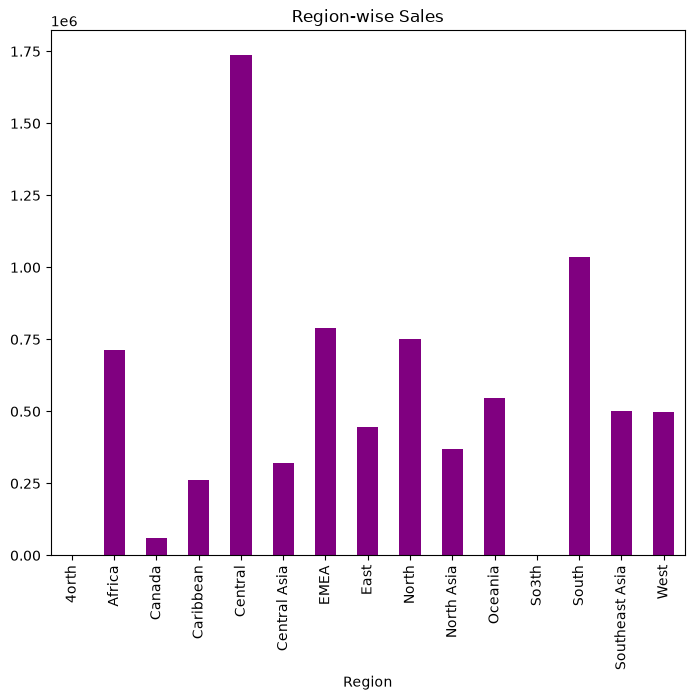

In [27]:
fig = plt.figure(figsize=(18,15))
plt.subplot(2,2,3)
region_sales = df.groupby("Region")["Sales"].sum()
region_sales.plot(kind="bar",color="purple")
plt.title("Region-wise Sales")

# Profit vs Discount

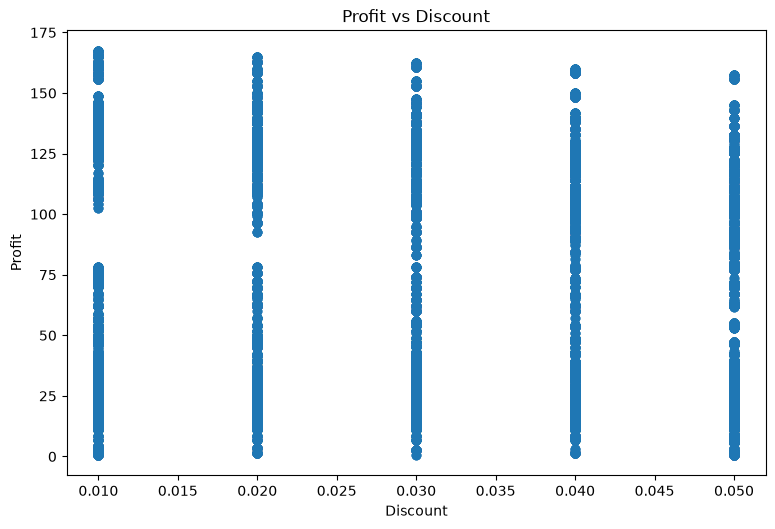

In [28]:
fig = plt.figure(figsize=(15,10))
plt.subplot(2,2,4)
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Profit vs Discount")

plt.tight_layout()
plt.show()

# -----------------------------
Additional Dashboard Reports
-----------------------------

In [30]:
print("\nTop 10 Products")
print(df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10))

print("\nTop 10 Customers")
print(df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10))

print("\nCountry-wise Sales")
print(df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10))

print("\nOrder Priority Distribution")
print(df["Order Priority"].value_counts())

print("\nShip Mode Performance")
print(df.groupby("Ship Mode")[["Sales","Shipping Cost","Aging"]].mean())

print("\nCorrelation Matrix")
print(corr)


Top 10 Products
Product
T - Shirts       692912.0
Titak watch      637260.0
Running Shoes    626080.0
Jeans            609092.0
Formal Shoes     595335.0
Shirts           547624.0
Fossil Watch     444564.0
Casula Shoes     340990.0
Suits            304655.0
Sports Wear      240295.0
Name: Sales, dtype: float64

Top 10 Customers
Customer Name
Mcclain O'Donnell    17015.0
Weber Halladay       16632.0
Leon Sissman         16321.0
Booth Pistole        16291.0
Ellis Carmichael     16174.0
Bates Gockenbach     15968.0
Bell Bickford        15932.0
Spears Thornton      15922.0
Graves Garza         15833.0
Flores Brooks        15807.0
Name: Sales, dtype: float64

Country-wise Sales
Country
United States     1562170.0
Australia          442452.0
France             437441.0
Mexico             418795.0
Germany            323619.0
China              296640.0
United Kingdom     253975.0
Brazil             247794.0
India              244746.0
Indonesia          222379.0
Name: Sales, dtype: float64



NameError: name 'corr' is not defined